# Machine Learning for Hydrologic Parameter Estimation

This notebook details the final stage of our project: the development, evaluation, and selection of machine learning models to predict the ModClark hydrologic parameters, Time of Concentration ($T_c$) and Storage Coefficient ($R$), from watershed geomorphological and land use characteristics.

Building upon the Exploratory Data Analysis (EDA) conducted previously ([see notebook here](15_exploratory_data_analysis.ipynb)), this notebook implements the machine learning workflow. We will train and compare a suite of models, ranging from interpretable linear regressions to powerful non-linear ensembles. The ultimate goal is to identify the best-performing model that can accurately and reliably estimate $T_c$ and $R$ for ungauged basins, providing a valuable tool for hydrological modeling.

## Modeling Strategy

The insights from our EDA directly inform a clear and targeted modeling strategy. The key decisions are outlined below:

* **Target Variable Transformation:** The EDA revealed that the target variables, $T_c$ and $R$, are right-skewed and their relationships with many features are non-linear. Therefore, to improve model performance and better satisfy the assumptions of linear models, we will model the **natural logarithm** of the targets: **$\log(T_c)$** and **$\log(R)$**.

* **Tailored Feature Preprocessing:** Our EDA showed that linear models require feature transformations to meet linearity assumptions, while non-linear models do not. Therefore, we will create two separate preprocessing pipelines:
    1.  **Pipeline for Linear Models (OLS, Elastic Net):** This pipeline will include the **feature transformations** (Log/Box-Cox) suggested by the bivariate analysis, followed by **Z-score standardization**.
    2.  **Pipeline for Non-Linear Models (Random Forest, SVM):** This pipeline will only perform **Z-score standardization**. While not strictly necessary for Random Forests, it is essential for SVM and ensures consistency.

* **Feature Selection Strategy:** To create more parsimonious and interpretable models, we will incorporate feature selection:
    * **For Linear Models:** For standard linear regression, we will drop small coefficients. For elastic net regression we will leverage the **L1 regularization component of Elastic Net** as our primary method for feature selection. By tuning its strength, the model will automatically drive the coefficients of less important or redundant features to zero, effectively selecting a simpler feature subset.
    * **For Non-Linear Models:** While models like Random Forest are robust to irrelevant features, feature selection can still improve performance and interpretability. We will use the **feature importances generated by an initial Random Forest** run to guide the selection of a more focused feature set if necessary.

## Model Training and Evaluation Workflow

We will follow a, multi-step process to ensure our model evaluation is unbiased and reliable. Two separate modeling pipelines will be developed, one for predicting $\log(T_c)$ and one for $\log(R)$.

1.  **Data Splitting:** The dataset will first be split into a **training/validation pool (80% of watersheds)** and a final **hold-out test set (20% of watersheds)**. This split will be performed based on `ws_id` to ensure that all data points from a single watershed reside in only one set, preventing data leakage.

2.  **Pipeline Construction:** For each model, we will use `scikit-learn`'s `Pipeline` object, incorporating the appropriate preprocessing steps (Transformation + Scaling for linear, Scaling only for non-linear).

3.  **Model Selection via Cross-Validation:** We will use **Group K-Fold Cross-Validation** on the training/validation pool, using `ws_id` as the grouping variable. Each of our candidate models—**Multiple Linear Regression, Elastic Net, SVM, and Random Forest**—will be trained and evaluated across all folds. This process will allow us to reliably compare their performance.

4.  **Final Model Training:** After identifying the best-performing model from cross-validation, it will be re-trained one last time on the **entire training/validation pool**.

5.  **Final Evaluation:** This final, retrained model will be evaluated on the **untouched hold-out test set** to provide the definitive, unbiased assessment of its ability to generalize to new, unseen watersheds.

## Performance Metrics
The models will be compared using a standard set of regression and hydrological metrics, including:
* **Root Mean Squared Error (RMSE)**
* **Nash-Sutcliffe Efficiency (NSE)**
* **Mean Absolute Percentage Error (MAPE) of Peak Flow**
* **Bias of Peak Flow**
* **Mean Absolute Error (MAE) of Time to Peak**
* **Bias of Total Volume**

**Note**:

Before running this notebook, a preprocess step was taken to compute and save the cell area for each watershed. The source file is [available here](../../src/hydrology/compute_cell_area.py).

In [1]:
# Set root folder for the project
from pathlib import Path

try:
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = Path.cwd() / "drive/My Drive/Data Science Project/ML-ModClark-IUH-Model"
  print(f"Project Root: {PROJECT_ROOT}")
except:
  # Project Root
  PROJECT_ROOT = Path.cwd().parent.parent
  print(f"Project Root: {PROJECT_ROOT}")

Project Root: /Users/alan/Data Science Projects/ML-ModClark-IUH-Model


In [2]:
# Add custom modules to the path
import sys

# Custom Modules
sys.path.append(str(PROJECT_ROOT / 'src'))

In [3]:
# Load dataframes
import pandas as pd
df_master_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master.csv"
df_recommendations_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/feature_transformation_recommendations.csv"

df_master = pd.read_csv(df_master_path, dtype={'ws_id':str})
df_recommendations = pd.read_csv(df_recommendations_path)

## 1. Data Splitting

In [4]:
import pandas as pd
import numpy as np

# --- Assume df_master is a pre-existing pandas DataFrame ---
# It must contain a 'ws_id' column.

#-------------------------------------------------------------------------------
## 1. Data Splitting (Group-Based)
#-------------------------------------------------------------------------------

print("--- Splitting data into Training Pool and Hold-Out Test Set ---")

# 1. Get a list of unique watershed IDs
unique_ws_ids = df_master['ws_id'].unique()
np.random.seed(42) # for reproducibility
np.random.shuffle(unique_ws_ids)

# 2. Split the list of watershed IDs into 80% and 20%
split_index = int(len(unique_ws_ids) * 0.8)
train_pool_ws_ids = unique_ws_ids[:split_index]
test_set_ws_ids = unique_ws_ids[split_index:]

# 3. Create the dataframes based on the split IDs
df_train_pool = df_master[df_master['ws_id'].isin(train_pool_ws_ids)].copy()
df_test = df_master[df_master['ws_id'].isin(test_set_ws_ids)].copy()


# --- Summary of the Split ---
print("\n--- Split Summary ---")
print(f"Total unique watersheds: {len(unique_ws_ids)}")
print(f"Watersheds in Training/Validation Pool: {len(train_pool_ws_ids)} (~80%)")
print(f"Watersheds in Hold-Out Test Set: {len(test_set_ws_ids)} (~20%)")
print("-" * 30)
print(f"Total data points: {len(df_master)}")
print(f"Data points in Training/Validation Pool: {len(df_train_pool)}")
print(f"Data points in Hold-Out Test Set: {len(df_test)}")

# Verify that there are no overlapping watersheds between the two sets
assert len(np.intersect1d(train_pool_ws_ids, test_set_ws_ids)) == 0
print("\nVerification successful: No watershed overlap between sets. ✅")

--- Splitting data into Training Pool and Hold-Out Test Set ---

--- Split Summary ---
Total unique watersheds: 112
Watersheds in Training/Validation Pool: 89 (~80%)
Watersheds in Hold-Out Test Set: 23 (~20%)
------------------------------
Total data points: 292
Data points in Training/Validation Pool: 226
Data points in Hold-Out Test Set: 66

Verification successful: No watershed overlap between sets. ✅


## 2. Pipeline Constructor

In [5]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# --- Assume df_master, and df_recommendations are pre-existing ---

#-------------------------------------------------------------------------------
## 2. Pipeline Construction (Dynamic and Robust to Zeros)
#-------------------------------------------------------------------------------

# --- Define custom classes and functions for robust transformations ---

def log_transform_safe(x):
    """Adds a small constant to handle log(0) issues."""
    epsilon = 1e-6
    return np.log(x + epsilon)

class SafePowerTransformer(BaseEstimator, TransformerMixin):
    """
    A wrapper for PowerTransformer that adds a small constant to handle
    zero values before applying the Box-Cox transformation.
    """
    def __init__(self, method='box-cox', standardize=True):
        self.method = method
        self.standardize = standardize
        self.epsilon = 1e-6
        self.transformer_ = PowerTransformer(method=self.method, standardize=self.standardize)

    def fit(self, X, y=None):
        # Shift data by epsilon before fitting
        X_shifted = X + self.epsilon
        self.transformer_.fit(X_shifted)
        return self

    def transform(self, X):
        # Shift data by epsilon before transforming
        X_shifted = X + self.epsilon
        return self.transformer_.transform(X_shifted)

# --- Main pipeline creation function ---

print("--- Building Preprocessing Pipelines Based on Recommendations ---")

def create_preprocessor_for_target(target_name, recommendations_df, feature_list):
    """Builds a preprocessing pipeline for a specific target variable."""

    rec_target = recommendations_df[recommendations_df['Target'] == target_name]

    log_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Log(x)']['Feature'].tolist() if f in feature_list]
    boxcox_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Box-Cox(x)']['Feature'].tolist() if f in feature_list]

    transformer_steps = []
    if log_features:
        transformer_steps.append(
            ('log', FunctionTransformer(log_transform_safe), log_features)
        )
    if boxcox_features:
        # Use the new SafePowerTransformer to handle potential zeros
        transformer_steps.append(
            ('power', SafePowerTransformer(method='box-cox'), boxcox_features)
        )

    feature_transformer = ColumnTransformer(
        transformers=transformer_steps,
        remainder='passthrough',
        force_int_remainder_cols=False
    )

    preprocessor_pipeline = Pipeline(steps=[
        ('feature_transformer', feature_transformer),
        ('scaler', StandardScaler())
    ])

    return preprocessor_pipeline

# --- Create the specific pipelines for TC and R ---
col_names = df_master.columns.tolist()
remove_cols = ['ws_id','year','tc','r']
features_to_analyze = [f for f in col_names if f not in remove_cols]
linear_preprocessor_tc = create_preprocessor_for_target('TC', df_recommendations, features_to_analyze)
linear_preprocessor_r = create_preprocessor_for_target('R', df_recommendations, features_to_analyze)


# --- Summary of Linear Pipelines ---
print("\n✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:")
print(linear_preprocessor_tc)

print("\n✅ Pipeline for Target 'R' ('linear_preprocessor_r') created:")
print(linear_preprocessor_r)

#-------------------------------------------------------------------------------
## 2.2 Pipeline for Non-Linear Models (Random Forest, SVM)
#-------------------------------------------------------------------------------

# This pipeline only scales the features, as transformations for linearity
# are not required for these models. Scaling is still essential for SVM.
nonlinear_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- Summary of Non-Linear Pipeline ---
print("\n✅ Pipeline for Non-Linear Models ('nonlinear_preprocessor') created:")
print(nonlinear_preprocessor)

--- Building Preprocessing Pipelines Based on Recommendations ---

✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:
Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<function log_transform_safe at 0x11c7bc220>),
                                                  ['sinuosity', 'pct_barren']),
                                                 ('power',
                                                  SafePowerTransformer(),
                                                  ['basin_area',
                                                   'centroidal_flowpath',
                                                   'main_channel_slope',
                                                   'flowpath_1085_slope',
                         

## 3. Model e Evaluation
## Multiple Linear Regression - $T_c$

In [6]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_validate

# --- Assume df_train_pool, df_test, features_to_analyze, ---
# --- linear_preprocessor_tc, and linear_preprocessor_r are pre-existing from previous steps ---

#-------------------------------------------------------------------------------
## 1. Cross-Validation on the Training Pool
#-------------------------------------------------------------------------------
print("--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---")

# Define data from the training pool
X_train = df_train_pool[features_to_analyze]
groups = df_train_pool['ws_id']

# Define the cross-validation strategy
cv = GroupKFold(n_splits=5)

# Define scoring metrics
scoring_metrics = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'] # For maximizing R-squared and minimizing RMSE/MAE

target = 'tc'
# Prepare target variable (using log transform)
y_train = np.log(df_train_pool[target])

# Create the full pipeline with the preprocessor and the regressor
model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Perform cross-validation
cv_scores_mlr_tc = cross_validate(model_pipeline_mlr_tc, X_train, y_train, groups=groups, cv=cv, scoring=scoring_metrics)

#-------------------------------------------------------------------------------
## 2. Final Training
#-------------------------------------------------------------------------------
print(f"--- Fitting Multiple Linear Regression Model on  {target.upper()} ---")

# Prepare the test data
X_test = df_test[features_to_analyze]

# Prepare training and test target variables
y_train = np.log(df_train_pool[target])
y_test_log = np.log(df_test[target])
y_test_original = df_test[target]

# Create the final pipeline
model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Train the final model on the ENTIRE training pool
model_pipeline_mlr_tc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log = model_pipeline_mlr_tc.predict(X_test)

# Inverse transform predictions back to the original scale
y_pred_original = np.exp(y_pred_log)

print("Training is complete.")


--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---
--- Fitting Multiple Linear Regression Model on  TC ---
Training is complete.



--- Model evaluation for target: TC - K-Fold Cross Validation---
Average Cross-Validation Scores (on log-transformed data):
  R-squared: -0.508
  RMSE: 0.744
  MAE: 0.558


--- Final Evaluation on Hold Out Test Set for target: TC ---

Performance on LOG-TRANSFORMED data:
  R-squared: -0.321
  RMSE: 0.543
  MAE: 0.448

Performance on ORIGINAL scale data:
  R-squared: -0.251
  RMSE: 5.679
  MAE: 4.743
--- Model Coefficients for Target ---
Intercept: 2.3972

                      Feature  Coefficient  Abs_Coefficient
16    compactness_coefficient     1.634365         1.634365
20          ruggedness_number     1.571529         1.571529
19               relief_ratio    -1.374484         1.374484
15               basin_relief    -1.238062         1.238062
7                  basin_area    -0.774048         0.774048
14                basin_slope    -0.251982         0.251982
13        flowpath_1085_slope    -0.213100         0.213100
8            drainage_density    -0.160020         0.160020

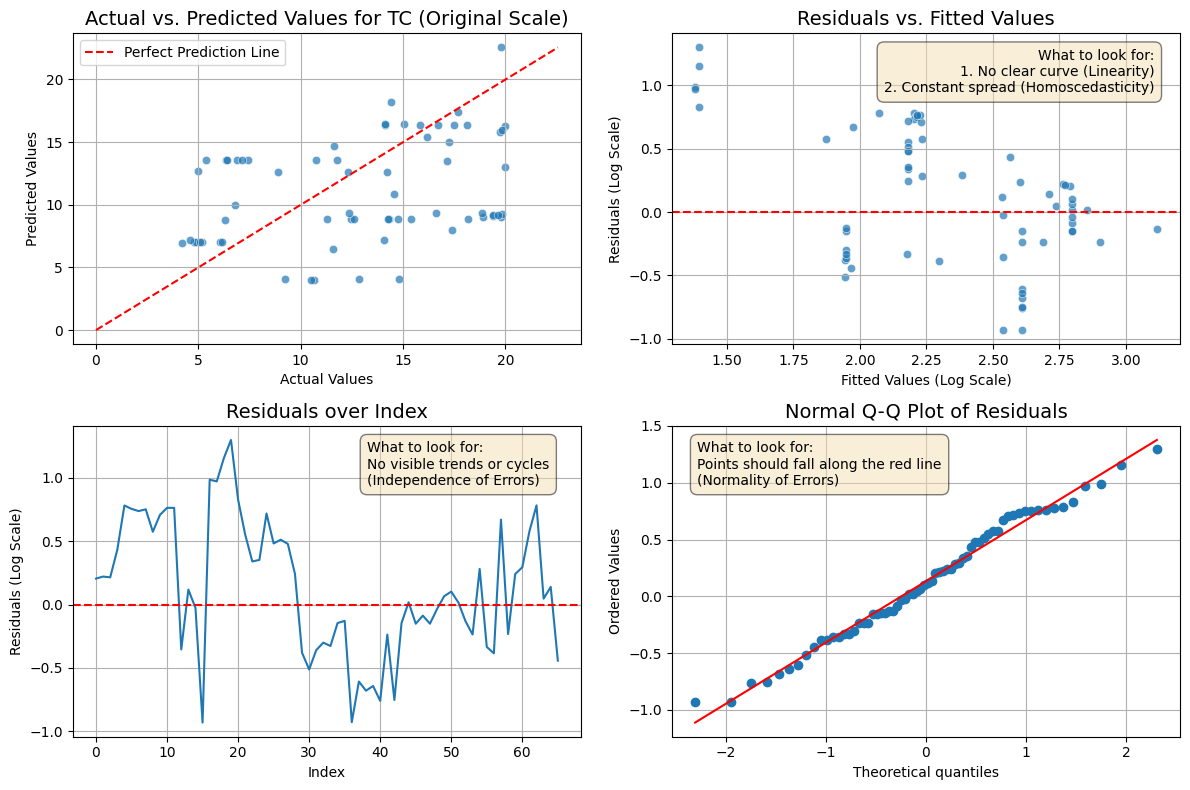

In [7]:
## Evaluation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


#-------------------------------------------------------------------------------
## 1. Performance Analysis: metrics
#-------------------------------------------------------------------------------

# Cross Validation Summary
print(f"\n--- Model evaluation for target: {target.upper()} - K-Fold Cross Validation---")

# Print average scores from cross-validation
print("Average Cross-Validation Scores (on log-transformed data):")
print(f"  R-squared: {np.mean(cv_scores_mlr_tc['test_r2']):.3f}")
print(f"  RMSE: {-np.mean(cv_scores_mlr_tc['test_neg_root_mean_squared_error']):.3f}")
print(f"  MAE: {-np.mean(cv_scores_mlr_tc['test_neg_mean_absolute_error']):.3f}")

# Final Evaluation Summary
print("\n" + "="*60)

print(f"\n--- Final Evaluation on Hold Out Test Set for target: {target.upper()} ---\n")
# Calculate and print final metrics
print("Performance on LOG-TRANSFORMED data:")
print(f"  R-squared: {r2_score(y_test_log, y_pred_log):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_log)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_log, y_pred_log):.3f}")

print("\nPerformance on ORIGINAL scale data:")
print(f"  R-squared: {r2_score(y_test_original, y_pred_original):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred_original)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_original, y_pred_original):.3f}")

#-------------------------------------------------------------------------------
## 2. Performance Analysis: coefficients
#-------------------------------------------------------------------------------

# 1. Extract the final step (the linear regression model)
regressor_step_mlr_tc = model_pipeline_mlr_tc.named_steps['regressor']

# 2. Extract the preprocessor step
preprocessor_step_mlr_tc = model_pipeline_mlr_tc.named_steps['preprocessor']

# 3. Get the coefficients and intercept
coefficients = regressor_step_mlr_tc.coef_
intercept = regressor_step_mlr_tc.intercept_

# 4. Get the feature names AFTER transformation from the preprocessor
# This is the crucial step to correctly match names and coefficients
try:
    # This works for ColumnTransformer
    transformed_feature_names = preprocessor_step_mlr_tc.get_feature_names_out()
except AttributeError:
    # Fallback for simpler preprocessors (like just a scaler)
    transformed_feature_names = features_to_analyze

# 5. Combine into a pandas DataFrame for easy viewing
df_coeffs = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': coefficients
})
df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)


print(f"--- Model Coefficients for Target ---")
print(f"Intercept: {intercept:.4f}\n")
print(df_coeffs)

#-------------------------------------------------------------------------------
## 3. Performance Analysis: Actual vs. Predicted and Model Assumptions
#-------------------------------------------------------------------------------

print("\n" + "="*60)
print("\n--- Variation Inflation Factor - VIF ---")
# 1. Multicollinearity check with Varition Inflation Factor
vif_subset = pd.DataFrame(linear_preprocessor_tc.fit_transform(X_train), columns=X_train.columns)
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_subset.columns
vif_data["VIF"] = [variance_inflation_factor(vif_subset.values, i)
                   for i in range(vif_subset.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=False))

# Calculate residuals on the log scale the model was trained on
residuals = y_test_log - y_pred_log
# Create a figure for diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
print(f"\n--- Actual v. Predicted and Model Assumptions: {target.upper()} ---\n\n")
# 2. Plot - Actual vs. Predicted (Original Scale)
sns.scatterplot(x=y_test_original, y=y_pred_original, ax=axes[0], alpha=0.7)
axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
max_val = max(y_test_original.max(), y_pred_original.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
axes[0].legend()
axes[0].grid(True)

# 3. Plot - Residuals vs. Fitted
sns.scatterplot(x=y_pred_log, y=residuals, ax=axes[1], alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Fitted Values', fontsize=14)
axes[1].set_xlabel('Fitted Values (Log Scale)')
axes[1].set_ylabel('Residuals (Log Scale)')
axes[1].grid(True)
axes[1].text(0.95, 0.95,
             'What to look for:\n1. No clear curve (Linearity)\n2. Constant spread (Homoscedasticity)',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 4. - Residuals over Index
sns.lineplot(x=np.arange(len(residuals)), y=residuals, ax=axes[2])
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title('Residuals over Index', fontsize=14)
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Residuals (Log Scale)')
axes[2].grid(True)
axes[2].text(-0.6, 0.95,
             'What to look for:\nNo visible trends or cycles\n(Independence of Errors)',
             transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 5. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[3])
axes[3].set_title('Normal Q-Q Plot of Residuals', fontsize=14)
axes[3].get_lines()[0].set_markerfacecolor('C0')
axes[3].get_lines()[0].set_markeredgecolor('C0')
axes[3].get_lines()[1].set_color('red')
axes[3].grid(True)
axes[3].text(0.05, 0.95,
             'What to look for:\nPoints should fall along the red line\n(Normality of Errors)',
             transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


#### Multiple Linear Regression (MLR) Results for Target: $T_c$

This section presents the performance evaluation and diagnostic analysis of the Multiple Linear Regression (MLR) model trained to predict the time of concentration ($T_c$).

##### Model Performance Evaluation

The performance of the MLR model was evaluated using both 5-fold group cross-validation on the training pool and a final evaluation on an unseen hold-out test set. The results unequivocally indicate that the model is not a suitable predictor for $T_c$.

The primary performance metric, **R-squared ($R^2$), was consistently negative** across all evaluations (Average CV $R^2$ = -0.508; Final Test $R^2$ = -0.321). A negative $R^2$ value signifies that the model's predictions are **worse than a baseline model that simply predicts the average $T_c$** for all watersheds. This demonstrates a fundamental failure of the model to capture the underlying relationships between the geomorphological/land-use features and the time of concentration. The high RMSE and MAE values on the original scale further confirm the model's poor predictive capability.

---
##### Analysis of Model Coefficients and Assumptions

An examination of the model coefficients reveals the likely cause of the model's failure: **severe multicollinearity**.

* **Model Instability:** The model assigns large, often counter-intuitive coefficients to highly correlated features. For example, `basin_relief` receives a large negative coefficient (-1.24), while the related `ruggedness_number` receives a large positive coefficient (+1.57). This is a classic sign of multicollinearity, where the model cannot disentangle the individual effects of correlated variables, leading to unstable and unreliable coefficient estimates.

  Multicollinearity, is numerically evidenced by the variation inflation factor - VIF: the VIF scores for c`ompactness_coefficient` ($\text~4769$) and `basin_relief` ($\text~4572$) are exceptionally high. This confirms that these features are extremely redundant with other variables in the model. The model has almost no reliable way to distinguish their individual effects.

  A large group of features exhibits high multicollinearity (VIF > 10). This includes all relief, ruggedness, shape, and size metrics, as well as several land use percentages. This isn't an isolated issue; it's a systemic property of the dataset where many features carry similar information.

  However, several features have low to moderate VIF scores, indicating they are relatively independent. These include `main_channel_slope` (1.6), `pct_forest` (1.9), `pct_developed` (2.6), and `flowpath_1085_slope` (2.8).

  Based on the VIF score, the following classes of multicollinearity are defined:
    - VIF = 1: No multicollinearity.
    - 1 < VIF < 5: multicollinearity weak to moderate.
    - VIF ≥ 5 ou 10: High multicollinearity or extreme.


* **Hydrologically Implausible Relationships:** Several key coefficients contradict fundamental hydrologic principles. The model assigns a negative coefficient to `basin_area` (-0.77), which incorrectly implies that larger watersheds have a shorter time of concentration. Furthermore, a key predictor identified in the EDA, `pct_developed`, has a coefficient near zero, suggesting its influence was suppressed by other correlated features.

* **Violation of Assumptions:**
  - *Homoscedasticity*: the pattern in error associated with the fitted values fails to meet homoscedasticity.
  - *No Multicollinearity*: As asserted above, the results strongly suggest that the strict assumptions of MLR—particularly the absence of multicollinearity and the presence of simple linear relationships—are not met by this complex environmental dataset. The model's poor performance is a direct consequence of these violated assumptions.
  - *Independence of Errors*: the presence of cycles in the "Residual over Index" plot, showes the model fails to meet the independence of errors.

---
##### How to Improve the Model

Given the poor performance and instability of the initial MLR model, several strategies can be employed to create a more robust and potentially more accurate linear model.

* **Manual Feature Selection to Reduce Multicollinearity:** The most direct approach to combat the instability caused by multicollinearity is to manually remove redundant features. Based on the correlation analysis from the EDA, we can create a more parsimonious model by selecting only one representative feature from each highly correlated group. For instance:
    * Retain `basin_area` as the primary size metric and drop `stream_length`, `basin_length`, and `overland_flow_path_length`.
    * Retain `main_channel_slope` as the primary slope metric and drop the highly correlated `flowpath_1085_slope` and `relief_ratio`.

* **Use of Regularized Regression:** Instead of manually dropping features with small coefficients, a more robust and automated approach is to use a model designed to handle this scenario, such as **Elastic Net Regression**. The L1 regularization component of Elastic Net will automatically shrink the coefficients of less important or redundant features, potentially forcing them to exactly zero. This performs a more data-driven form of feature selection and stabilizes the model in the presence of multicollinearity (it's the next algorithm on the list).

* **Intercept:** Forcing the intercept to zero (`fit_intercept=False`) is generally **not recommended** in this case. There is no strong physical basis to assume that $T_c$ would be 1 (since we are modeling $\log(T_c)$) when all predictor variables are at their mean value (which is what zero represents after standardization). Doing so would likely introduce significant bias into the model's coefficients and performance.

---

Bellow, we drop variable with high multicollineraty in an attempt to improve the MLR model.

##### Improvement of MLR model for $T_c$

In [10]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm

# Load the correlation matrix from the CSV file
corr_matrix_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/correlation_matrix.csv"
corr_matrix = pd.read_csv(corr_matrix_path, index_col=0)

# --- Assume create_preprocessor_for_target ---
# --- df_train_pool, df_test, and df_recommendations are pre-existing. ---

# Define help function
def select_features(corr_matrix, threshold=0.5):
    """
    Select a subset of features with correlations below the specified threshold.

    Parameters:
    - corr_matrix (pd.DataFrame): Correlation matrix with features as rows and columns.
    - threshold (float): Maximum allowed absolute correlation between any two features.

    Returns:
    - list: List of selected feature names.
    """
    features = list(corr_matrix.index)
    remaining_features = features.copy()

    while True:
        # Extract sub-matrix for remaining features
        sub_matrix = corr_matrix.loc[remaining_features, remaining_features]

        # Find pairs with absolute correlation above threshold, excluding self-correlations
        high_corr_pairs = [
            (i, j) for i in remaining_features for j in remaining_features
            if i < j and abs(sub_matrix.loc[i, j]) > threshold
        ]

        # If no high-correlation pairs remain, we're done
        if not high_corr_pairs:
            break

        # Count how many times each feature appears in high-correlation pairs
        feature_counts = Counter([feature for pair in high_corr_pairs for feature in pair])

        # Remove the feature with the most high-correlation pairs
        feature_to_remove = max(feature_counts, key=feature_counts.get)
        remaining_features.remove(feature_to_remove)

    return remaining_features


def train_and_evaluate_mlr(target, CORR_THRESHOLD, VIF_THRESHOLD, COEFF_THRESHOLD, display_plot=True):
    """
    Trains and evaluates a Multiple Linear Regression model with a multi-step feature selection process.

    This workflow:
      1. Selects features with low multicollinearity based on correlation and VIF.
      2. Fits a temporary model on the selected features.
      3. Ranks coefficients and drops features with coefficients below a threshold.
      4. Retrains and evaluates the final model on the refined feature set.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        CORR_THRESHOLD (float): Maximum allowed absolute correlation between any two features.
        VIF_THRESHOLD (float): Maximum allowed VIF for a feature.
        COEFF_THRESHOLD (float): Minimum absolute coefficient value to retain a feature.

    Returns:
        (Pipeline, list): A tuple containing the final trained model pipeline and the final list of selected features.
    """
    print("\n" + "="*80)
    print(f"--- Starting MLR Workflow for Target: {target.upper()} ---")
    print("="*80)

    #-------------------------------------------------------------------------------
    ## 1. Select features with low multicollinearity
    #-------------------------------------------------------------------------------
    print(f"\n--- Selecting features with low multicollinearity (Correlation Threshold: {CORR_THRESHOLD}) ---")
    suggested_features = select_features(corr_matrix, threshold=CORR_THRESHOLD)

    preprocessor_vif = create_preprocessor_for_target(target.upper(), df_recommendations, suggested_features)
    transformed_xtrain_array = preprocessor_vif.fit_transform(df_train_pool[suggested_features])

    print("\nCalculating VIF for Suggested Features ---")
    vif_subset = pd.DataFrame(transformed_xtrain_array, columns=suggested_features)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = vif_subset.columns
    vif_data["VIF"] = [variance_inflation_factor(vif_subset.values, i) for i in range(vif_subset.shape[1])]

    selected_features_vif = vif_data[vif_data['VIF'] < VIF_THRESHOLD]['Feature'].tolist()
    print(vif_data.sort_values(by='VIF', ascending=False))

    if len(selected_features_vif) < len(suggested_features):
      dropped_features = vif_data[vif_data['VIF'] >= VIF_THRESHOLD]['Feature'].tolist()
      print("\nThe following features were dropped due to high VIF:")
      print(dropped_features)

    #-------------------------------------------------------------------------------
    ## 2. Fit Temporary Model
    #-------------------------------------------------------------------------------
    print(f"\nFitting Temporary Model on {target.upper()} with VIF-Selected Features...")
    X_train_temp = df_train_pool[selected_features_vif]
    y_train = np.log(df_train_pool[target])

    temp_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, selected_features_vif)
    temp_model_pipeline = Pipeline(steps=[
        ('preprocessor', temp_preprocessor),
        ('regressor', LinearRegression())
    ])
    temp_model_pipeline.fit(X_train_temp, y_train)

    #-------------------------------------------------------------------------------
    ## 3. Rank coefficients and select final features
    #-------------------------------------------------------------------------------
    print(f"\nSelecting final features based on coefficient influence (Threshold: {COEFF_THRESHOLD})")
    regressor_step = temp_model_pipeline.named_steps['regressor']
    preprocessor_step = temp_model_pipeline.named_steps['preprocessor']
    coefficients = regressor_step.coef_

    try:
        transformed_feature_names = preprocessor_step.get_feature_names_out()
    except AttributeError:
        transformed_feature_names = selected_features_vif

    df_coeffs = pd.DataFrame({'Feature': transformed_feature_names, 'Coefficient': coefficients})
    df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()

    final_selected_features = df_coeffs[df_coeffs['Abs_Coefficient'] > COEFF_THRESHOLD]['Feature'].tolist()

    if len(final_selected_features) < len(selected_features_vif):
      dropped_features = df_coeffs[df_coeffs['Abs_Coefficient'] <= COEFF_THRESHOLD]['Feature'].tolist()
      print(f"\nThe following features were dropped due to low coefficient (< {COEFF_THRESHOLD}): ---")
      print(dropped_features)

    #-------------------------------------------------------------------------------
    ## 4. Retrain and Evaluate the Final Model
    #-------------------------------------------------------------------------------
    print("\n" + "="*60)
    print(f"Fitting and Evaluating Final Model for {target.upper()} ...")

    X_train_final = df_train_pool[final_selected_features]
    X_test_final = df_test[final_selected_features]
    y_train_log = np.log(df_train_pool[target])
    y_test_log = np.log(df_test[target])
    y_test_original = df_test[target]

    final_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, final_selected_features)
    final_model_pipeline = Pipeline(steps=[
        ('preprocessor', final_preprocessor),
        ('regressor', LinearRegression())
    ])
    final_model_pipeline.fit(X_train_final, y_train_log)

    y_pred_log = final_model_pipeline.predict(X_test_final)
    y_pred_original = np.exp(y_pred_log)

    # --- Final Evaluation Summary ---
    log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
    orignal_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
    hours, minutes = convert_fractional_hours_to_hm(orignal_metrics['Bias'])

    print(f"\nFinal Model Evaluation on Hold-Out Test Set for target: {target.upper()}\n")
    print("Performance on LOG-TRANSFORMED data:")
    print(f"  R-squared: {log_metrics['R2']:.3f}")
    print(f"  RMSE: {log_metrics['RMSE']:.3f} hrs")
    print(f"  MAPE: {log_metrics['MAPE']:.1f}")
    print(f"  Bias: {log_metrics['Bias']:.3f} hrs")

    print("\nPerformance on ORIGINAL scale data:")
    print(f"  R-squared: {orignal_metrics['R2']:.3f}")
    print(f"  RMSE: {orignal_metrics['RMSE']:.3f} hrs")
    print(f"  MAPE: {orignal_metrics['MAPE']:.1f}")
    print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

    # --- Final Coefficients ---
    final_regressor = final_model_pipeline.named_steps['regressor']
    final_preprocessor_step = final_model_pipeline.named_steps['preprocessor']
    try:
        final_transformed_names = final_preprocessor_step.get_feature_names_out()
    except AttributeError:
        final_transformed_names = final_selected_features

    df_final_coeffs = pd.DataFrame({'Feature': final_transformed_names, 'Coefficient': final_regressor.coef_})
    df_final_coeffs['Abs_Coefficient'] = df_final_coeffs['Coefficient'].abs()

    print(f"\nFinal Model Coefficients for Target: {target.upper()}")
    print(f"    Intercept: {final_regressor.intercept_:.4f}\n")
    print(df_final_coeffs.sort_values(by='Abs_Coefficient', ascending=False))

    if display_plot:
      print("\n")
      # --- Diagnostic Plots ---
      residuals = y_test_log - y_pred_log
      fig, axes = plt.subplots(2, 2, figsize=(12, 8))
      axes = axes.flatten()

      # Plot - Actual vs. Predicted (Original Scale)
      sns.scatterplot(x=y_test_original, y=y_pred_original, ax=axes[0], alpha=0.7)
      axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
      axes[0].set_xlabel('Actual Values')
      axes[0].set_ylabel('Predicted Values')
      max_val = max(y_test_original.max(), y_pred_original.max())
      axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
      axes[0].legend()
      axes[0].grid(True)

      # Plot - Residuals vs. Fitted
      sns.scatterplot(x=y_pred_log, y=residuals, ax=axes[1], alpha=0.7)
      axes[1].axhline(y=0, color='red', linestyle='--')
      axes[1].set_title('Residuals vs. Fitted Values', fontsize=14)
      axes[1].set_xlabel('Fitted Values (Log Scale)')
      axes[1].set_ylabel('Residuals (Log Scale)')
      axes[1].grid(True)
      axes[1].text(0.95, 0.95,
                  'What to look for:\n1. No clear curve (Linearity)\n2. Constant spread (Homoscedasticity)',
                  transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                  horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

      # Residuals over Index
      sns.lineplot(x=np.arange(len(residuals)), y=residuals, ax=axes[2])
      axes[2].axhline(y=0, color='red', linestyle='--')
      axes[2].set_title('Residuals over Index', fontsize=14)
      axes[2].set_xlabel('Index')
      axes[2].set_ylabel('Residuals (Log Scale)')
      axes[2].grid(True)
      axes[2].text(-0.6, 0.95,
                  'What to look for:\nNo visible trends or cycles\n(Independence of Errors)',
                  transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
                  horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

      # Q-Q Plot
      stats.probplot(residuals, dist="norm", plot=axes[3])
      axes[3].set_title('Normal Q-Q Plot of Residuals', fontsize=14)
      axes[3].get_lines()[0].set_markerfacecolor('C0')
      axes[3].get_lines()[0].set_markeredgecolor('C0')
      axes[3].get_lines()[1].set_color('red')
      axes[3].grid(True)
      axes[3].text(0.05, 0.95,
                  'What to look for:\nPoints should fall along the red line\n(Normality of Errors)',
                  transform=axes[3].transAxes, fontsize=10, verticalalignment='top',
                  horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
      plt.tight_layout()
      plt.show()

      # Distribution of residuals
      residuals_original = y_test_original - y_pred_original
      fig, axes = plt.subplots(1, 2, figsize=(12, 4))
      axes = axes.flatten()
      sns.histplot(residuals, kde=True, bins=30, ax=axes[0]) # kde=True adds a kernel density estimate line
      axes[0].set_title(f'Distribution of Residuals (Log Scale)', fontsize=14)
      axes[0].set_xlabel('Residual Value (Log Scale)')
      axes[0].set_ylabel('Frequency')
      axes[0].grid(True)
      plt.tight_layout()

      sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1]) # kde=True adds a kernel density estimate line
      axes[1].set_title(f'Distribution of Residuals', fontsize=14)
      axes[1].set_xlabel('Residual Value (Original Scale)')
      axes[1].set_ylabel('Frequency')
      axes[1].grid(True)
      plt.tight_layout()
      plt.show()

    return final_model_pipeline, final_selected_features



--- Starting MLR Workflow for Target: TC ---

--- Selecting features with low multicollinearity (Correlation Threshold: 0.5) ---

Calculating VIF for Suggested Features ---
                    Feature       VIF
2               basin_slope  3.656419
7           pct_grass_scrub  2.965734
5                 sinuosity  2.829006
3   compactness_coefficient  2.092098
6             pct_developed  1.904415
10               pct_barren  1.880288
4               form_factor  1.677110
0          drainage_density  1.628568
1        main_channel_slope  1.552937
8              pct_wetlands  1.342141
9                 pct_water  1.298357

The following features were dropped due to high VIF:
['basin_slope', 'sinuosity', 'pct_grass_scrub']

Fitting Temporary Model on TC with VIF-Selected Features...

Selecting final features based on coefficient influence (Threshold: 0.02)

Fitting and Evaluating Final Model for TC ...

Final Model Evaluation on Hold-Out Test Set for target: TC

Performance on LOG-TRANS

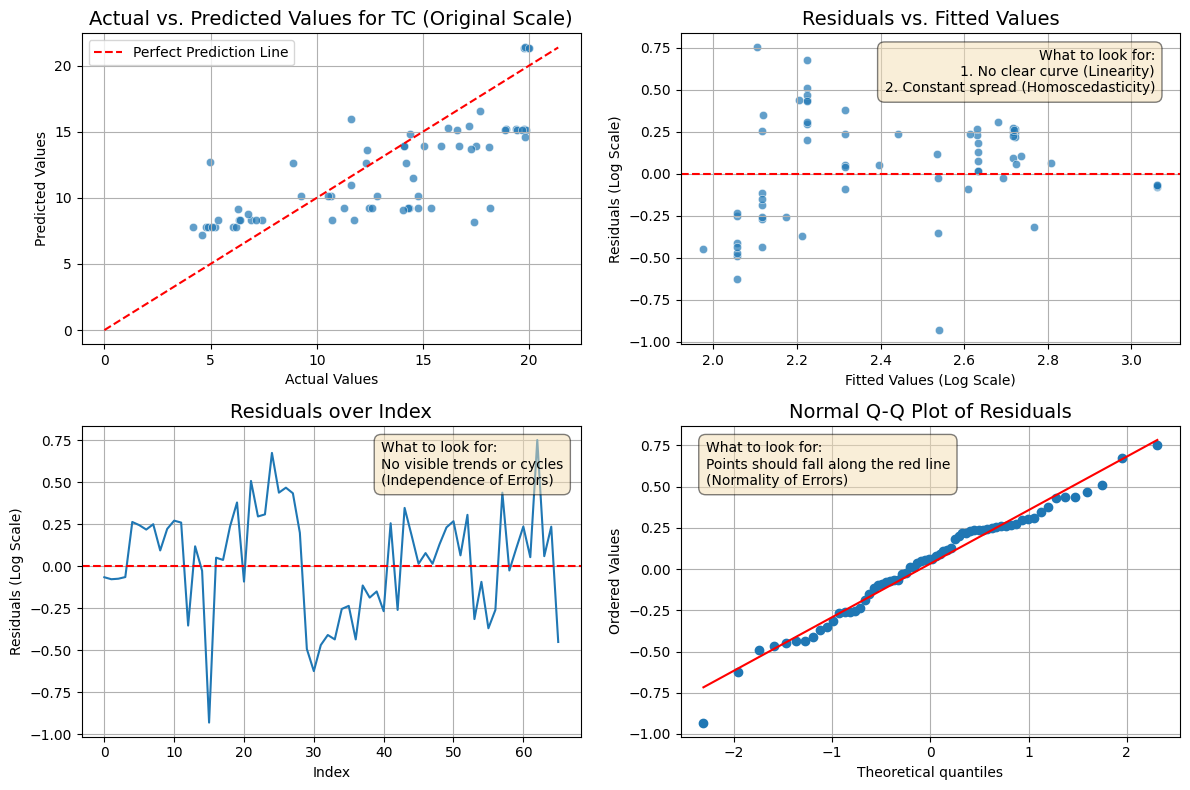

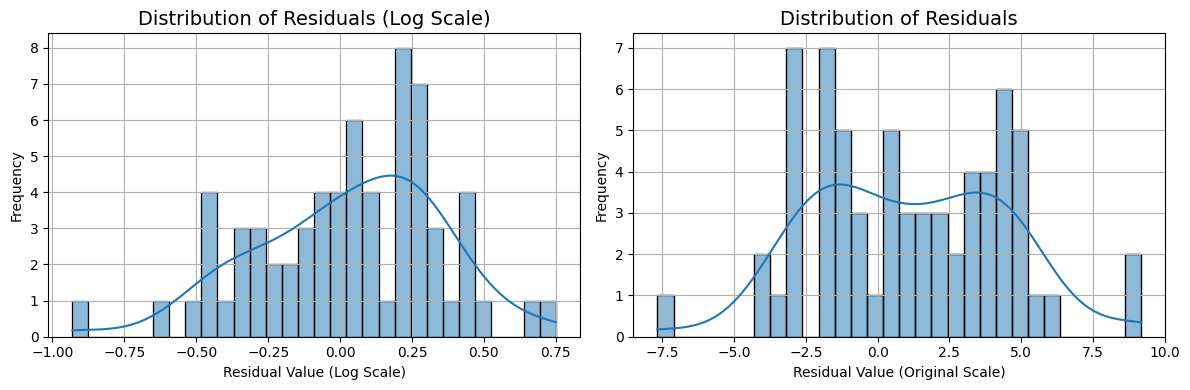

In [11]:
# Rum model for target Tc
CORR_THRESHOLD = 0.5
VIF_THRESHOLD = 2.5
COEFF_THRESHOLD = 0.02

final_model_r, final_features_r = train_and_evaluate_mlr('tc', CORR_THRESHOLD, VIF_THRESHOLD, COEFF_THRESHOLD, True)

#### Analysis of the Final Multiple Linear Regression Model for Time of Concentration ($T_c$)

The following analysis provides a an evaluation of the final Multiple Linear Regression (MLR) model developed to predict the time of concentration ($T_c$). The model was constructed following a rigorous, multi-stage feature selection process to mitigate the effects of multicollinearity observed in the initial EDA.

##### Overall Model Performance

The multi-step feature selection strategy, which filtered predictors based on correlation, Variance Inflation Factor (VIF), and coefficient magnitude (not as important as others), proved to be highly effective. The resulting model is stable and demonstrates a moderately useful predictive capability, establishing a solid baseline for this study.

On the hold-out test set, the model achieved an **R-squared of 0.538** on the log-transformed data and **0.528 on the original scale**. This indicates that the final set of eight selected features can explain approximately 53% of the variance in the time of concentration. While this leaves a significant portion of the variance unexplained, it represents a substantial improvement over an unregularized model and confirms that a meaningful statistical relationship has been learned. The Root Mean Squared Error (RMSE) on the original scale is **3.487**, which can be interpreted as the typical magnitude of prediction error in hours ($T_c$ is in hours).

---
#### Interpretation of Model Coefficients

The feature selection process has yielded a more interpretable set of coefficients. However, the results present a mix of hydrologically consistent relationships and some counter-intuitive findings that highlight the limitations of a linear approach.

* **Hydrologically Consistent Predictors:** Several coefficients align well with established hydrologic principles:
    * **`pct_barren` (-0.26):** The strongest predictor. The negative coefficient correctly implies that a higher percentage of barren land leads to a *faster* response (lower $T_c$), likely due to reduced infiltration and quicker runoff generation.
    * **`form_factor` (-0.17):** A negative coefficient indicates that basins with a lower form factor (i.e., more elongated) have a *longer* $T_c$, which is physically sound.
    * **`main_channel_slope` (-0.04):** As expected, steeper channel slopes lead to a *faster* response.
    * **`pct_wetlands` (+0.02):** A positive, albeit small, coefficient correctly suggests that the presence of wetlands provides storage and *slows down* the watershed response (higher $T_c$).

* **Counter-intuitive and Potentially Unstable Predictors:**
    * **`drainage_density` (+0.18):** This coefficient is contrary to typical hydrologic theory, which posits that higher drainage density creates a more efficient network and thus a *faster* response (lower $T_c$). This positive coefficient may be an artifact of confounding variables not captured in the model or remaining subtle multicollinearity.
    * **`pct_developed` (+0.13):** This is the most significant inconsistency. The positive coefficient implies that more development *slows down* the watershed response. This directly contradicts the known effects of impervious surfaces. This result strongly suggests that even after feature selection, the linear model is unable to correctly isolate the true, complex impact of urbanization from other correlated factors.

---
#### Conclusions

The final MLR model represents a successful application of feature selection to overcome the model instability observed initially. It serves as a valuable, interpretable baseline with moderate predictive power.

However, the presence of several hydrologically inconsistent coefficients is a clear signal that a simple linear model is insufficient to fully capture the complex, non-linear interactions that govern watershed response. The model's struggles with variables like `drainage_density` and `pct_developed` highlight these limitations.

**Recommendation:** This model's performance and diagnostic analysis strongly justify moving forward with the planned **non-linear models (Random Forest, SVM)**. These advanced methods are well-suited to handle the complex interactions and non-linearities that the MLR model cannot, and they are expected to yield both higher predictive accuracy and more robust insights into the true drivers of $T_c$.

However, for an excercise, Elastic Net will be tested next.

## Multiple Linear Regression - $R$


--- Starting MLR Workflow for Target: R ---

--- Selecting features with low multicollinearity (Correlation Threshold: 0.5) ---

Calculating VIF for Suggested Features ---
                    Feature       VIF
3   compactness_coefficient  3.407078
9                 pct_water  2.446264
10               pct_barren  2.425654
0          drainage_density  2.405975
7           pct_grass_scrub  2.394911
5                 sinuosity  2.235034
6             pct_developed  2.018155
4               form_factor  1.909321
8              pct_wetlands  1.821667
2               basin_slope  1.780994
1        main_channel_slope  1.669281

The following features were dropped due to high VIF:
['drainage_density', 'compactness_coefficient', 'pct_water', 'pct_barren']

Fitting Temporary Model on R with VIF-Selected Features...

Selecting final features based on coefficient influence (Threshold: 0.05)

Fitting and Evaluating Final Model for R ...

Final Model Evaluation on Hold-Out Test Set for target: R

P

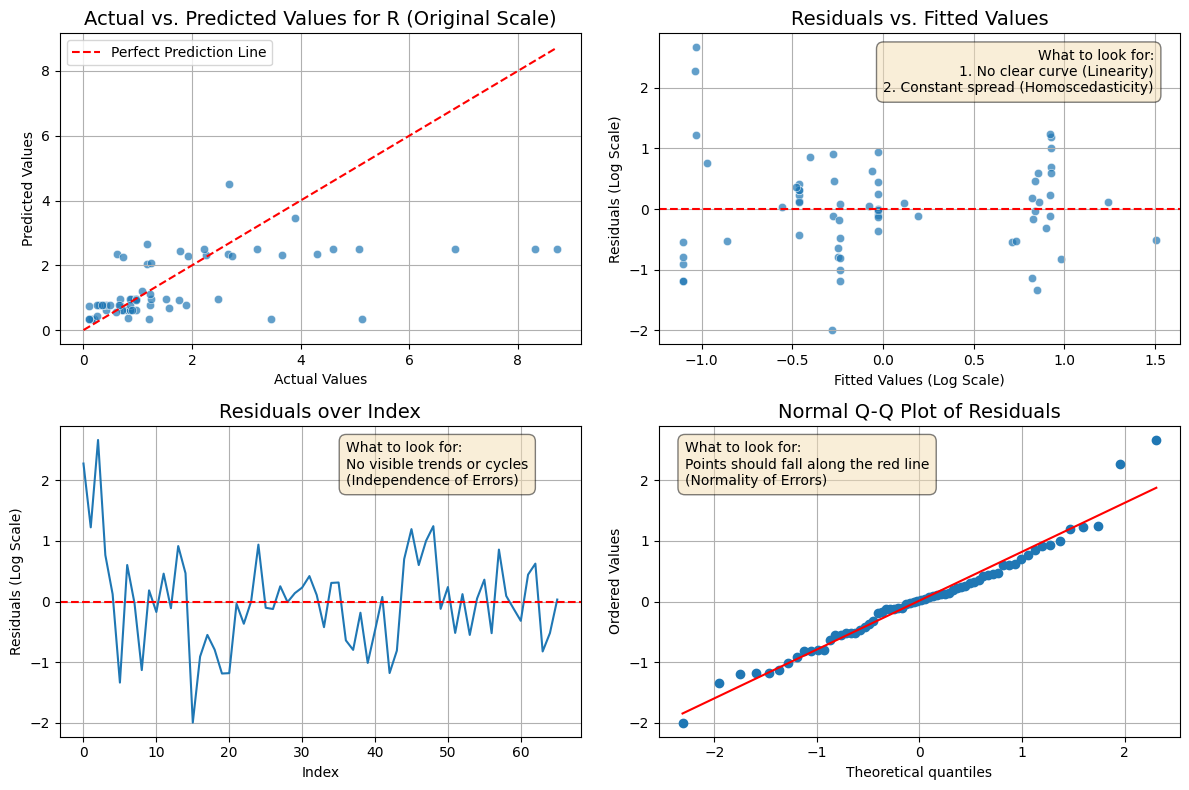

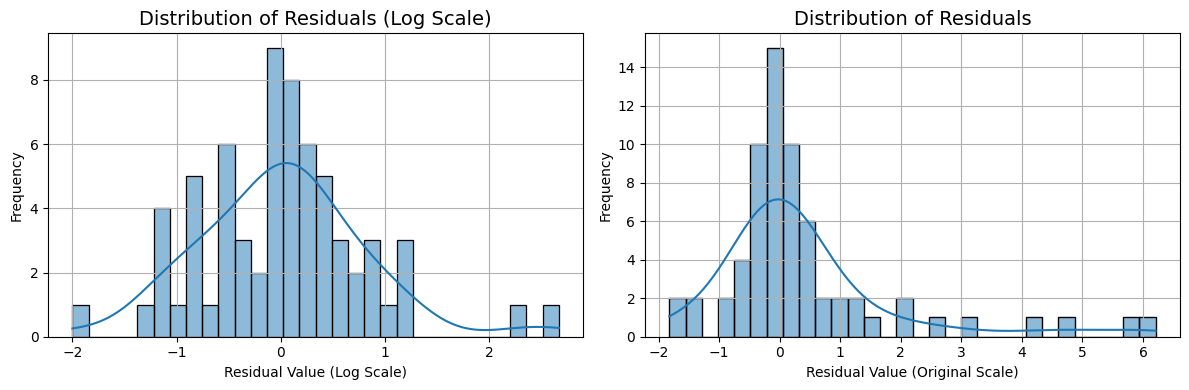

In [12]:
# Rum model for target R
CORR_THRESHOLD = 0.5
VIF_THRESHOLD = 2.4
COEFF_THRESHOLD = 0.05

final_model_r, final_features_r = train_and_evaluate_mlr('r', CORR_THRESHOLD, VIF_THRESHOLD, COEFF_THRESHOLD, True)

#### Brief on MLR Model for Target: R

This analysis summarizes the results of the Multiple Linear Regression (MLR) model trained to predict the storage coefficient ($R$).

##### Model Performance

The feature selection process yielded a stable model, but its predictive power is limited. The model achieved an **R-squared of 0.428** on the log-transformed data, which dropped significantly to **0.276 on the original scale**. This indicates the model explains only about 28% of the variance in $R$ and struggles to accurately predict the magnitude of higher storage values. The model serves as a weak baseline, demonstrating that a simple linear approach is not sufficient for this target.

---
##### Coefficient Interpretation

While the model is statistically stable, an examination of the coefficients reveals a mix of hydrologically sound and inconsistent relationships.

* **Consistent with Hydrology:** The model correctly identified that increased **`pct_wetlands`** (+) increases storage, while increased **`pct_developed`** (-), **`main_channel_slope`** (-), and a less compact shape (lower **`form_factor`** (-)) decrease storage.

* **Inconsistent with Hydrology:** The model produced two major counter-intuitive coefficients. It suggests that higher **`sinuosity`** (-) and higher **`basin_slope`** (+) lead to decreased and increased storage, respectively. These findings contradict established hydrologic principles, where higher sinuosity and lower slopes are typically associated with greater storage.

---
#### Conclusion

The MLR model for $R$ is a poor predictor. The combination of low predictive power and several hydrologically inconsistent coefficients strongly suggests that the complex, non-linear processes governing watershed storage cannot be adequately captured by a linear model (at least for our dataset). More advanced, non-linear models are necessary to improve performance and gain more reliable insights.

Alternative would be to test more transformations on dependent variable to increase linearity.  

## Elastic Net - $T_c$

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)



def train_and_evaluate_ElasticNet(target,
                                  n_alphas = 500,
                                  l1_ratio = [.1, .2, .3, .4, .5, .6, .7, .8, .9, .93, .95, .97, .99, 1],
                                  n_folds=35,
                                  max_iter=10000,
                                  display_plot=True):
    """
    Trains and evaluates an ElasticNet Regression model with CV and grid search.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        n_alphas (int): number of alphas to test (automatically generated).
        l1_ratio (List [float]): list of l1 ratio to test.
        max_iter (int): Max number of interation.
        display_plot (bool): Whether to display diagnostic plots.

    Returns:
        Pipeline: The final trained model pipeline.
        """
    # --- Assume df_train_pool, df_test, ---
    # --- create_preprocessor ,are pre-existing from previous steps ---

    #-------------------------------------------------------------------------------
    ## 1. Preprocessing
    #-------------------------------------------------------------------------------

    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id','year','tc','r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]
    linear_preprocessor_tc = create_preprocessor_for_target('TC', df_recommendations, features_to_analyze)
    linear_preprocessor_r = create_preprocessor_for_target('R', df_recommendations, features_to_analyze)
    groups = df_train_pool['ws_id']  # Group labels

    create_preprocessor_for_target(target.upper(), df_recommendations, features_to_analyze)

    # Define data from the training pool
    X_train = df_train_pool[features_to_analyze].copy()

    # Prepare target variable (using log transform)
    y_train = np.log(df_train_pool[target])

    cv = GroupKFold(n_splits=n_folds)
    #-------------------------------------------------------------------------------
    ## 2. Training
    #-------------------------------------------------------------------------------
    print(f"--- Fitting ElasticNet Search Grid CV Model on  {target.upper()}... ---")

    # Create the final pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', linear_preprocessor_tc),
        ('regressor', ElasticNetCV(n_alphas = n_alphas, l1_ratio = l1_ratio, cv=cv, max_iter=max_iter, random_state=42))
    ])

    # Train the final model on the ENTIRE training pool
    model_pipeline.fit(X_train, y_train, groups = groups)

    print("    Training is complete.")

    #-------------------------------------------------------------------------------
    ## 3. Performance analysis
    #-------------------------------------------------------------------------------
    print("\n--- Pipeline Schema ---")
    display(model_pipeline)

    # Prepare the test data
    X_test = df_test[features_to_analyze]

    # Prepare training and test target variables
    y_train = np.log(df_train_pool[target])
    y_test_log = np.log(df_test[target])
    y_test_original = df_test[target]

    # Make predictions on the test set
    y_pred_log = model_pipeline.predict(X_test)

    # Inverse transform predictions back to the original scale
    y_pred_original = np.exp(y_pred_log)

    # Evaluation Summary
    print("\n" + "="*60)
    print(f"\n--- Evaluation on Hold Out Test Set for target: {target.upper()} ---\n")

    # Calculate and print  metrics
    print("Performance on LOG-TRANSFORMED data:")
    print(f"  R-squared: {r2_score(y_test_log, y_pred_log):.3f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_log)):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test_log, y_pred_log):.3f}")

    print("\nPerformance on ORIGINAL scale data:")
    print(f"  R-squared: {r2_score(y_test_original, y_pred_original):.3f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred_original)):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test_original, y_pred_original):.3f}")

    # Extract model
    model = model_pipeline.named_steps['regressor']

    # Extract preprocessor
    preprocessor = model_pipeline.named_steps['preprocessor']

    # Get the coefficients and intercept
    coefficients = model.coef_
    intercept = model.intercept_

    # Get the feature names AFTER transformation from the preprocessor
    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
    except AttributeError:
        transformed_feature_names = features_to_analyze

    # Combine into a pandas DataFrame
    df_coeffs = pd.DataFrame({
        'Feature': transformed_feature_names,
        'Coefficient': coefficients
    })
    df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
    df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)
    df_coeffs = df_coeffs[df_coeffs['Abs_Coefficient'] != 0]

    print(f"\n--- Model Coefficients for Target ---")
    print(f"Intercept: {intercept:.4f}\n")
    print(df_coeffs)

    # Retrieve optimal alpha and l1_ratio
    optimal_alpha = model.alpha_
    optimal_l1_ratio = model.l1_ratio_

    print(f"\nOptimal alpha: {round(optimal_alpha,4)}")
    print(f"Optimal l1_ratio: {optimal_l1_ratio}")

    if display_plot:
      # Distribution of residuals
      residuals_original = y_test_original - y_pred_original
      fig, axes = plt.subplots(1, 2, figsize=(12, 4))
      axes = axes.flatten()

      # Plot - Actual vs. Predicted (Original Scale)
      print("\n")
      sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7, ax = axes[0])
      axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
      axes[0].set_xlabel('Actual Values')
      axes[0].set_ylabel('Predicted Values')
      max_val = max(y_test_original.max(), y_pred_original.max())
      min_val = (min(y_test_original.min(), y_pred_original.min()))
      axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
      axes[0].legend()
      axes[0].grid(True)

      sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1]) # kde=True adds a kernel density estimate line
      axes[1].set_title(f'Distribution of Residuals', fontsize=14)
      axes[1].set_xlabel('Residual Value (Original Scale)')
      axes[1].set_ylabel('Frequency')
      axes[1].grid(True)
      plt.tight_layout()
      plt.show()

    return model_pipeline


--- Fitting ElasticNet Search Grid CV Model on  TC... ---
    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x7ab5cda38ae0>),
                                                                   ['sinuosity',
                                                                    'pct_barren']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'centroidal_flowpath',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'compactness_coefficient',
                                                                    'overland_flow_path_length',
                                                                    'pct_developed',
                                                                    'pct_agriculture'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor',
                 ElasticNetCV(cv=35,
                              l1_ratio=[0.95, 0.97, 0.98, 0.985, 0.99, 0.995,
                                        0.999, 1],
                              n_alphas=500, random_state=42))])



--- Evaluation on Hold Out Test Set for target: TC ---

Performance on LOG-TRANSFORMED data:
  R-squared: 0.370
  RMSE: 0.375
  MAE: 0.322

Performance on ORIGINAL scale data:
  R-squared: 0.371
  RMSE: 4.027
  MAE: 3.544

--- Model Coefficients for Target ---
Intercept: 2.3972

                Feature  Coefficient  Abs_Coefficient
13  flowpath_1085_slope    -0.186087         0.186087
1            pct_forest     0.118918         0.118918
17          form_factor     0.089984         0.089984
8      drainage_density    -0.084353         0.084353
5             pct_water    -0.021383         0.021383
12   main_channel_slope    -0.011592         0.011592

Optimal alpha: 0.0342
Optimal l1_ratio: 1.0




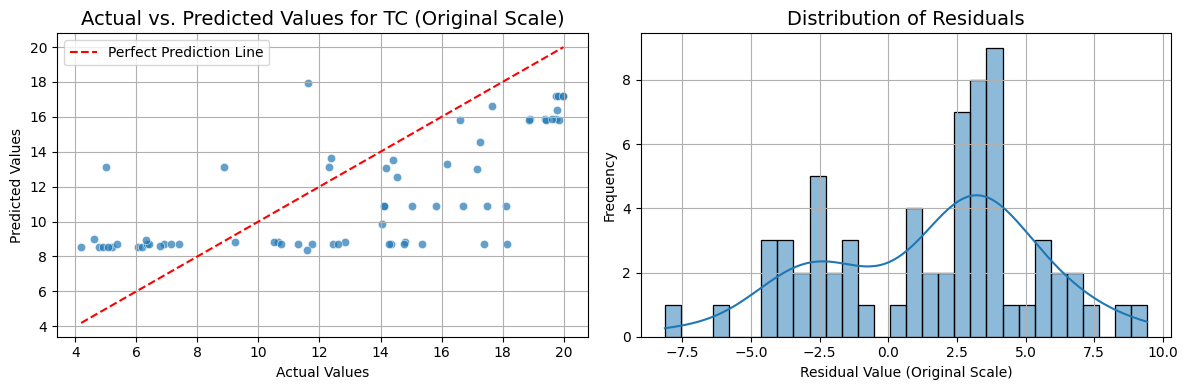

In [ ]:
ElasticNet_model_tc = train_and_evaluate_ElasticNet("tc",
                                  n_alphas = 500,
                                  l1_ratio = [.95, .97, .98, .985, .99, .995, .999, 1],
                                  n_folds=35,
                                  max_iter=1000,
                                  display_plot=True)

## Elastic Net- $R$

--- Fitting ElasticNet Search Grid CV Model on  R... ---
    Training is complete.

--- Pipeline Schema ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_transformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('log',
                                                                   FunctionTransformer(func=<function log_transform_safe at 0x7ab5cda38ae0>),
                                                                   ['sinuosity',
                                                                    'pct_barren']),
                                                                  ('power',
                                                                   SafePowerTransformer(),
                                                                   ['basin_area',
                                                                    'centroidal_flowpath',
                                                                    'main_channel_slope',
                                                                    'flowpath_1085_slope',
                                                                    'compactness_coefficient',
                                                                    'overland_flow_path_length',
                                                                    'pct_developed',
                                                                    'pct_agriculture'])])),
                                 ('scaler', StandardScaler())])),
                ('regressor',
                 ElasticNetCV(cv=70,
                              l1_ratio=[0.15, 0.2, 0.21, 0.22, 0.23, 0.3],
                              n_alphas=500, random_state=42))])



--- Evaluation on Hold Out Test Set for target: R ---

Performance on LOG-TRANSFORMED data:
  R-squared: 0.210
  RMSE: 0.939
  MAE: 0.660

Performance on ORIGINAL scale data:
  R-squared: 0.259
  RMSE: 1.588
  MAE: 0.922

--- Model Coefficients for Target ---
Intercept: 0.1732

                      Feature  Coefficient  Abs_Coefficient
3             pct_grass_scrub    -0.341251         0.341251
4                pct_wetlands    -0.328483         0.328483
19               relief_ratio    -0.286214         0.286214
0               pct_developed     0.252346         0.252346
17                form_factor     0.201687         0.201687
8            drainage_density    -0.189230         0.189230
18           elongation_ratio    -0.187708         0.187708
21  overland_flow_path_length     0.176409         0.176409
1                  pct_forest     0.133974         0.133974
10               basin_length     0.118645         0.118645
12         main_channel_slope    -0.114237         0.114237

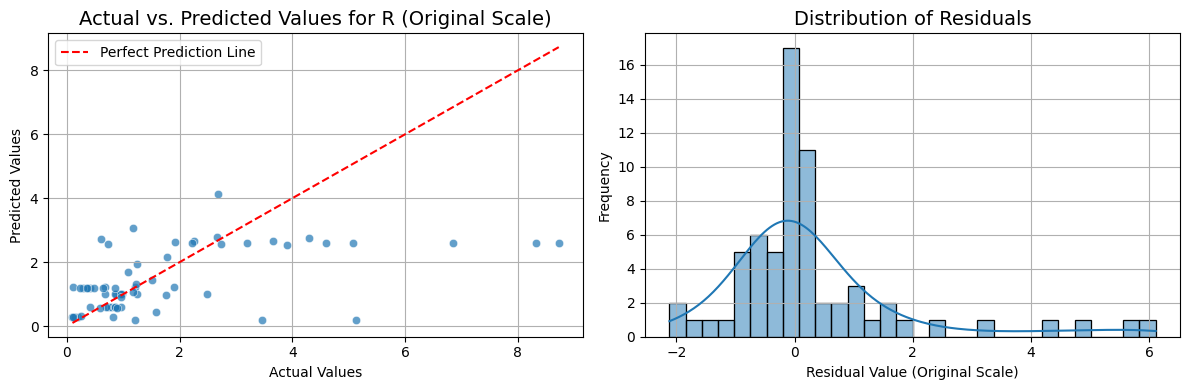

In [ ]:
ElasticNet_model_r = train_and_evaluate_ElasticNet("r",
                                  n_alphas = 500,
                                  l1_ratio = [.15, .2, .21, .22, .23, .3],
                                  n_folds=70,
                                  max_iter=1000,
                                  display_plot=True)

## Support Vector Regression - $T_c$

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def train_and_evaluate_SVR(target,
                            kernels = ['rbf', 'linear'],
                            Cs = [0.1, 1, 10, 100],
                            gammas= ['scale', 'auto'],
                            n_folds = 5,
                            display_plot=True):
    """
    Trains and evaluates an ElasticNet Regression model with CV and grid search.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        n_alphas (int): number of alphas to test (automatically generated).
        l1_ratio (List [float]): list of l1 ratio to test.
        max_iter (int): Max number of interation.
        display_plot (bool): Whether to display diagnostic plots.

    Returns:
        Pipeline: The final trained model pipeline.
        """
    # --- Assume df_train_pool and df_test are pre-existing from previous steps ---

    #-------------------------------------------------------------------------------
    ## 1. Preprocessing
    #-------------------------------------------------------------------------------
    print("--- Preprocessing: scaling features, created grid and setting up cross validation ---")

    # Define features and target
    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]

    X_train = df_train_pool[features_to_analyze].copy()
    y_train = np.log(df_train_pool[target])
    groups = df_train_pool['ws_id']  # Group labels

    # Define pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    # Define parameter grid
    param_grid = {
        'svr__kernel': kernels,
        'svr__C': Cs,
        'svr__gamma': gammas
    }

    # Define group-aware cross-validator
    group_kfold = GroupKFold(n_splits=n_folds)

    # Grid search with group-aware CV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=group_kfold,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    # Fit the model with group labels
    grid_search.fit(X_train, y_train, groups=groups)

    #-------------------------------------------------------------------------------
    ## 2. Train
    #-------------------------------------------------------------------------------
    print(f"\n--- Fitting Support Vector Regression Model on {target.upper()} with Grid Search and Cross Validation... ---")

    # Fit the model
    grid_search.fit(X_train, y_train)
    print('Fitting is complete.')
    #-------------------------------------------------------------------------------
    ## 3. Performance analysis
    #-------------------------------------------------------------------------------
    print("\n--- Pipeline Schema ---")
    display(pipeline)

    # Prepare the test data
    X_test = df_test[features_to_analyze]

    # Evaluate on test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Prepare training and test target variables
    y_train = np.log(df_train_pool[target])
    y_test_log = np.log(df_test[target])
    y_test_original = df_test[target]

    # Make predictions on the test set
    y_pred_log = best_model.predict(X_test)

    # Inverse transform predictions back to the original scale
    y_pred_original = np.exp(y_pred_log)

    # Evaluation Summary
    print("\n" + "="*60)
    print(f"\n--- Evaluation on Hold Out Test Set for target: {target.upper()} ---\n")

    print("Best Parameters:", grid_search.best_params_)
    # Calculate and print  metrics
    print("\nPerformance on LOG-TRANSFORMED data:")
    print(f"  R-squared: {r2_score(y_test_log, y_pred_log):.3f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_log)):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test_log, y_pred_log):.3f}")

    print("\nPerformance on ORIGINAL scale data:")
    print(f"  R-squared: {r2_score(y_test_original, y_pred_original):.3f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred_original)):.3f}")
    print(f"  MAE: {mean_absolute_error(y_test_original, y_pred_original):.3f}")

    return best_model


In [21]:
a = train_and_evaluate_SVR('tc',
                        kernels = ['rbf', 'linear'],
                        Cs = [0.1, 1, 10, 100],
                        gammas= ['scale', 'auto'],
                        n_folds = 5,
                        display_plot=True)

--- Preprocessing: scaling features, created grid and setting up cross validation ---

--- Fitting Support Vector Regression Model on TC with Grid Search and Cross Validation... ---


ValueError: The 'groups' parameter should not be None.